In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("/home/users/mm2947/jupyter/DMD/dmd_qbo")))
#from dmd_functions import *
from dmd_functions_adapted import *
import numpy as np
import pygeode as pyg
from matplotlib import pyplot as plt
import xarray as xr
from pydmd import EDMD
from pydmd.preprocessing import hankel_preprocessing
import scipy.signal
import pandas as pd
from matplotlib.offsetbox import AnchoredText
import textwrap
from math import ceil

%matplotlib widget

In [2]:
# ----------------------------
# Load data
# ----------------------------
model = "E3SM_PDINT"
#file_name = "E3SM_PDINT_anom_clim_detrend_smooth_1"
file_name = "E3SM_PDINT_anom_smooth_1"
data_file_out = '/home/users/mm2947/jupyter/processed_data/E3SM/' + file_name + '.nc'
#data_file_out = '/home/users/mm2947/jupyter/processed_data/ERA5/era5_daily_processedanom_smooth.nc'
ds = xr.open_dataset(data_file_out)

print(ds)

<xarray.Dataset>
Dimensions:  (time: 360, pres: 19, lat: 70)
Coordinates:
  * time     (time) object 0011-01-16 12:00:00 ... 0040-12-16 12:00:00
  * pres     (pres) float64 10.0 11.0 13.0 15.0 17.0 ... 100.0 115.0 130.0 150.0
  * lat      (lat) float64 -34.5 -33.5 -32.5 -31.5 -30.5 ... 31.5 32.5 33.5 34.5
Data variables:
    o3       (time, lat, pres) float32 ...
    t        (time, lat, pres) float32 ...
    u        (time, lat, pres) float32 ...
    v        (time, lat, pres) float32 ...
    w        (time, lat, pres) float32 ...
Attributes: (12/50)
    Conventions:             CF-1.8 QUOCA
    activity_id:             QUOCA
    activity_participation:  QUOCA
    branch_method:           standard
    branch_time_in_child:    0.0
    branch_time_in_parent:   0.0
    ...                      ...
    title:                   E3SM output prepared for QUOCA
    variable_id:             o3
    variant_label:           r1i1p1f1
    license:                 QUOCA model data produced by E3SM 

# **Use Fourier Transform to extract QBO period**

In [3]:
def area_weighted_trop_mean(ds, var, lat_band):
    ds_trop = ds.sel(lat=lat_band).sortby('pres')
    wlat = np.cos(np.deg2rad(ds_trop['lat']))
    A = ds_trop[var].weighted(wlat).mean('lat').transpose('pres', 'time')
    return A

def select_or_bandmean(A, p_target=None, p_band=None):

    if (p_target is None) == (p_band is None):
        raise ValueError("Choose exactly one of p_target or p_band.")

    if p_target is not None:
        ts = A.sel({'pres': p_target}, method="nearest")
        return ts, float(ts['pres'].values)

    pmin, pmax = p_band
    lo, hi = (pmin, pmax) if pmin < pmax else (pmax, pmin)
    band = A.sel({'pres': slice(lo, hi)})
    ts = band.mean('pres')
    return ts, (lo, hi)

def detrend(y):    
    y = np.asarray(y, float)
    m = np.isfinite(y)
    
    if m.sum() < 3:
        return y*np.nan
    x = np.arange(y.size)
    p = np.polyfit(x[m], y[m], 1)
    y_dt = y - (p[0]*x + p[1])
    return y_dt

def fft_spectrum(y, dt=1.0):    
    y = np.asarray(y, float)
    m = np.isfinite(y)
    if not np.all(m):
        y = y[m]
    n = y.size
    y = y - np.mean(y)
    
    Y = np.fft.rfft(y)
    f = np.fft.rfftfreq(n, d=dt)
    amp = (2.0 / n) * np.abs(Y)
    amp[0] = amp[0] / 2.0
    return f, amp

Largest peak: 25.71 months
2nd peak:     12.00 months


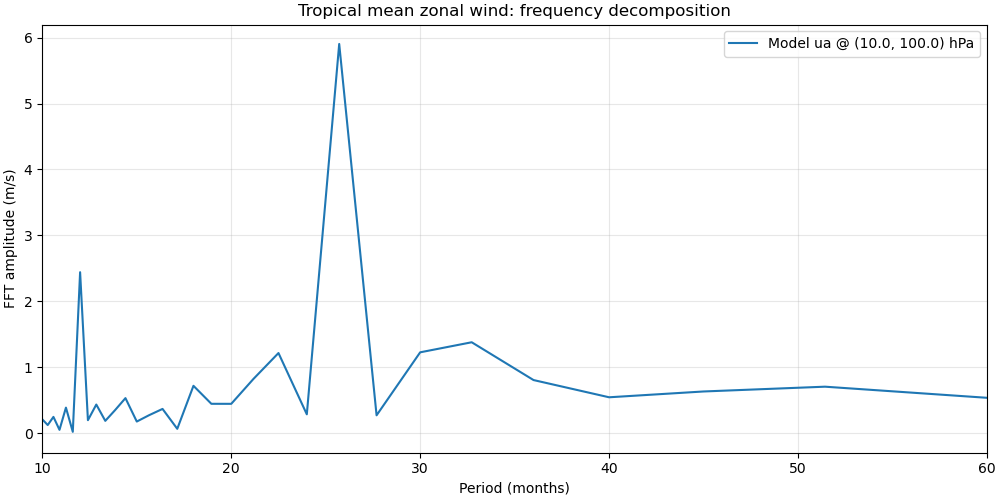

In [4]:
# ----------------------------
# Build 1D time series from each dataset
# ----------------------------

# Choose ONE set the other to none:
p_target = None     # hPa, e.g. 50
p_band = (10.0, 100.0)        # e.g. (30.0, 70.0)
FT_lat_band = slice(-10,10)
A = area_weighted_trop_mean(ds, var='u', lat_band = FT_lat_band)
ts, psel = select_or_bandmean(A, p_target, p_band)

# ----------------------------
# Detrend + FFT
# ----------------------------

y = detrend(ts.values)

# monthly sampling -> dt=1 month
f, amp = fft_spectrum(y, dt=1.0)

# Convert frequency to period (months), avoid f=0
mask = f > 0
period_months = 1.0 / f[mask]

# Extract periods associated with the 2 largest amplitudes
amps = amp[mask]                 # same length as period_months
top2 = np.argsort(amps)[-2:]     # indices of 2 largest (unsorted)
top2 = top2[np.argsort(amps[top2])[::-1]]  # sort so [0]=largest, [1]=second

FT_peak1 = period_months[top2[0]]
FT_peak2 = period_months[top2[1]]

print(f"Largest peak: {FT_peak1:.2f} months")
print(f"2nd peak:     {FT_peak2:.2f} months")

# ----------------------------
# Plot amplitude vs period (months/years)
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

ax.plot(period_months, amp[mask], label=f"Model ua @ {psel} hPa")

# Useful axis choices for QBO-ish signals:
#ax.set_xscale("log")          # periods span 2..200+ months nicely
ax.invert_xaxis()             # long periods on left, short on right (optional)
ax.set_xlabel("Period (months)")
ax.set_ylabel("FFT amplitude (m/s)")
ax.set_title("Tropical mean zonal wind: frequency decomposition")
ax.legend()
ax.set_xlim(10, 60)
ax.grid(True, which="both", alpha=0.3)

plt.show()

# **DMD parameters and data matrix assembling**

In [5]:
# ----------------------------
# Data settings
# ----------------------------
pres_min = ds.pres.values.min()       # hPa
pres_max = ds.pres.values.max()       # hPa
lat_min = ds.lat.values.min()
lat_max = ds.lat.values.max()
lat_band = (-10, 10)
#lat_band = (FT_lat_band.start, FT_lat_band.stop)
lat_min = get_index(lat_band[0], ds.lat.values)
lat_max = get_index(lat_band[1], ds.lat.values)

#input_vars = ["u", "t", "v"]
input_vars = ["u", "t"]

print(ds)

# ----------------------------
# Convenience definitions
# ----------------------------
dt       = 1.0       
qbo_period = FT_peak1
qbo_band = (qbo_period - 2, qbo_period + 2)
pres_plot = 50.0
u_levs = np.linspace(-20, 20, 11)
T_levs = np.linspace(-1.4, 1.4, 11)

# ----------------------------
# DMD settings
# ----------------------------
#d = int(np.round(qbo_period)*3.0)
d = int(np.round(qbo_period)*3.0)
stab_threshold = 0.01

# ----------------------------
# Output settings
# ----------------------------
save = True
save_dir = '/home/users/mm2947/jupyter/output'

config_str = f"{model}_edmd.png"

<xarray.Dataset>
Dimensions:  (time: 360, pres: 19, lat: 70)
Coordinates:
  * time     (time) object 0011-01-16 12:00:00 ... 0040-12-16 12:00:00
  * pres     (pres) float64 10.0 11.0 13.0 15.0 17.0 ... 100.0 115.0 130.0 150.0
  * lat      (lat) float64 -34.5 -33.5 -32.5 -31.5 -30.5 ... 31.5 32.5 33.5 34.5
Data variables:
    o3       (time, lat, pres) float32 ...
    t        (time, lat, pres) float32 ...
    u        (time, lat, pres) float32 ...
    v        (time, lat, pres) float32 ...
    w        (time, lat, pres) float32 ...
Attributes: (12/50)
    Conventions:             CF-1.8 QUOCA
    activity_id:             QUOCA
    activity_participation:  QUOCA
    branch_method:           standard
    branch_time_in_child:    0.0
    branch_time_in_parent:   0.0
    ...                      ...
    title:                   E3SM output prepared for QUOCA
    variable_id:             o3
    variant_label:           r1i1p1f1
    license:                 QUOCA model data produced by E3SM 

In [6]:
# ----------------------------
# Standardise and form data matrix X
# ----------------------------

std_option = 3
stds = []
std_data = []

for v in input_vars:
    data = ds[v]
    
    if std_option == 0:
        # Height-dependent std
        std = 1.0 / ds[v].std(axis=0, ddof=1).values
    elif std_option == 1:
        # Scalar std
        std = 1.0 / ds[v].std(ddof=1).values
    elif std_option == 2:
        # Variance-normalisation
        std = 1.0 / np.sqrt(np.var(np.asarray(ds[v]), axis=0) + 1e-8)
    elif std_option == 3:
        # density & area weighting
        lat_w = np.cos(np.deg2rad(ds.lat.values))  
        
        # dp weight (proportional to mass per unit area)
        p = ds.pres.values
        dp = np.empty_like(p)
        dp[1:-1] = 0.5 * (p[2:] - p[:-2])
        dp[0] = p[1] - p[0]
        dp[-1] = p[-1] - p[-2]
        dp = np.abs(dp)
        
        # combined grid weight w(lat,p) proportional to area * thickness
        w = lat_w[None, :] * dp[:, None]                   # (nlat, npres)

        std = w / ds[v].std(ddof=1).values

    stds.append(std)
    std_data.append((ds[v] * std.T).T.values)

# Arrange into DMD snapshot matrix X
X = np.stack(std_data, axis=0)
dshape = X.shape
print(X.shape)

n_time = X.shape[-1]
assert n_time == len(ds.time)
X2d = X.reshape(-1, n_time)
nfeatures, ntime = X2d.shape
print(X2d.shape)

(2, 19, 70, 360)
(2660, 360)


In [7]:
# ----------------------------
# Conditioning checks
# ----------------------------

print("dtype:", X2d.dtype, "shape:", X2d.shape)
print("NaNs:", np.isnan(X2d).sum(), "infs:", np.isinf(X2d).sum())
print("finite fraction:", np.isfinite(X2d).mean())

bad = ~np.isfinite(X2d)
print("Bad rows:", np.sum(bad.any(axis=1)), "Bad cols:", np.sum(bad.any(axis=0)))

dtype: float64 shape: (2660, 360)
NaNs: 0 infs: 0
finite fraction: 1.0
Bad rows: 0 Bad cols: 0


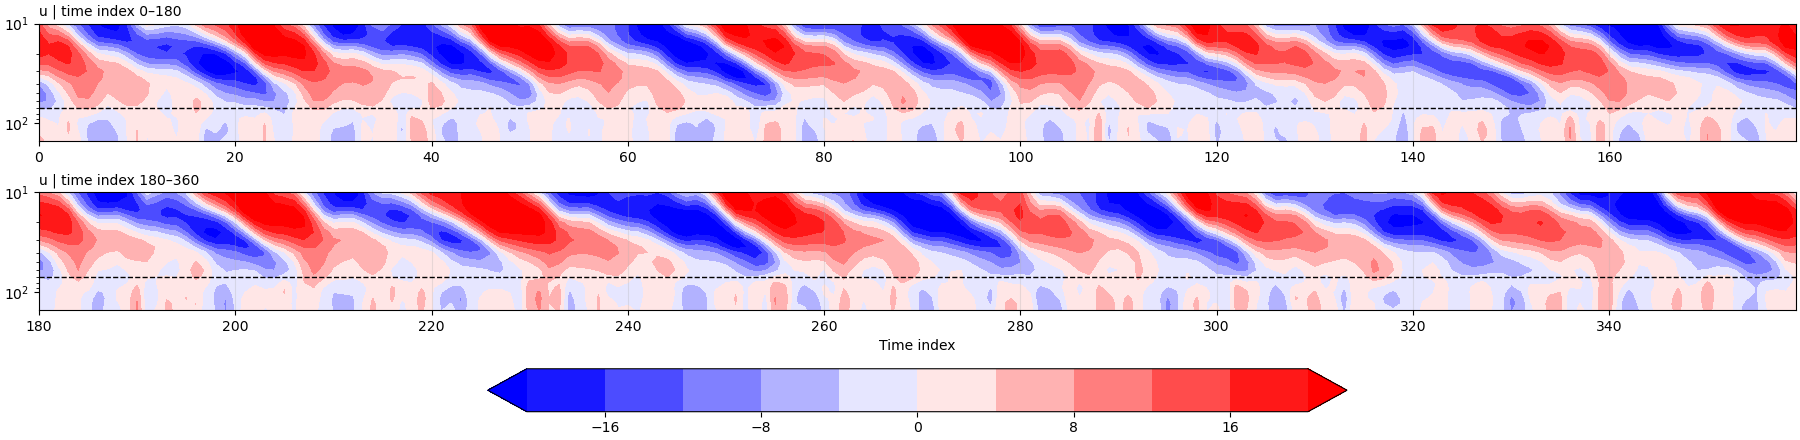

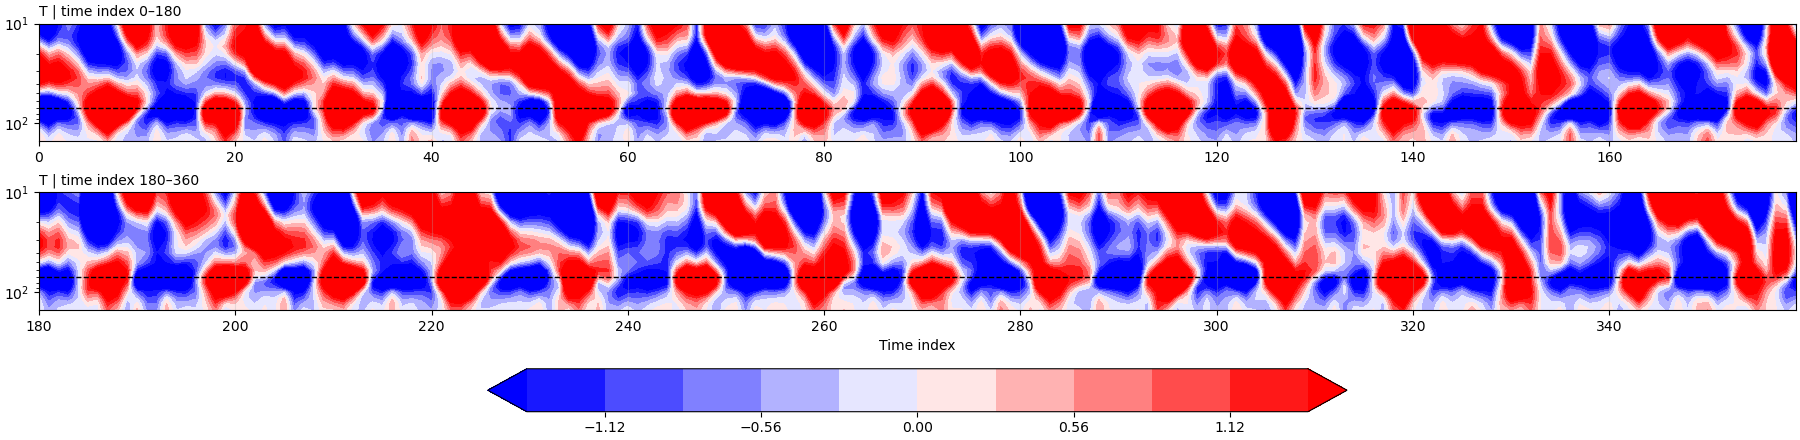

In [8]:
# ----------------------------
# Visualise data via tropical mean (WRAPPED)
# ----------------------------
#labels = ['u', 'T', 'v']
labels = ['u', 'T']

# how many time points per row (auto: ~5 rows total)
def compute_points_per_row(nt, target_rows=2):
    return max(1, nt // target_rows)

for i, var in enumerate(std_data):

    var = (var.T / stds[i].T).T
    levs = u_levs if i == 0 else T_levs

    # Assumes latitude is second axis
    trop_mean = np.mean(var[:, lat_min:lat_max], axis=1)
    nt = trop_mean.shape[1]

    points_per_row = compute_points_per_row(nt)
    nrows = int(np.ceil(nt / points_per_row))

    fig, axs = plt.subplots(
        nrows, 1,
        figsize=(18, 2.2 * nrows),
        sharey=True,
        constrained_layout=True
    )
    axs = np.atleast_1d(axs)

    for r in range(nrows):
        i0 = r * points_per_row
        i1 = min((r + 1) * points_per_row, nt)

        x = np.arange(i0, i1)        # numeric time index
        Z = trop_mean[:, i0:i1]

        ax = axs[r]
        im = ax.contourf(
            x, ds.pres.values, Z,
            levels=levs, cmap='bwr', extend='both'
        )

        # ax.set_yscale('log')
        # ax.invert_yaxis()
        ax.axhline(70.0, color='k', ls='--', lw=1.0)
        ax.grid(True, axis='x', alpha=0.3)

        # label each row so it's obvious what's happening
        ax.set_title(f"{labels[i]} | time index {i0}–{i1}", loc='left', fontsize=10)

        if r < nrows - 1:
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Time index")

    for ax in axs:
        ax.set_yscale('log')

    axs[0].invert_yaxis()   # only once, on the master
    
    fig.colorbar(im, ax=axs, location='bottom')
    plt.show()


# **Kernel Patching**

In [9]:
# ----------------------------
# NLSA kernel (Szekely et al., 2016)
# ----------------------------

def nlsa_kernel(X, Y=None, *, epsilon=None, speed_floor=1e-12):
    """
    Székely et al. (2016) eq.(2):

      K_ij = exp( -||x_i - y_j||^2 / (epsilon * ||zeta_i|| * ||zeta_j||) )
      zeta_i = x_i - x_{i-1} is the phase-space velocity  (rows time-ordered within each array)

    Returns: (nX, nY) ndarray.
    """
    
    same = False
    if Y is None:
        Y = X
        same = True

    if epsilon is None:
        epsilon = 1.0
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")

    def phase_space_velocity(A):
        n = A.shape[0]
        if n == 0:
            return np.empty((0,), dtype=float)
        if n == 1:
            return np.ones((1,), dtype=float)
        dA = np.empty_like(A)
        dA[1:] = A[1:] - A[:-1]  # backward difference
        dA[0] = dA[1]            # boundary fix
        v = np.linalg.norm(dA, axis=1)
        return np.maximum(v, speed_floor)

    vx = phase_space_velocity(X)
    vy = vx if same else phase_space_velocity(Y)

    # squared distances: ||x-y||^2 = ||x||^2 + ||y||^2 - 2 x·y
    # could be done using linalg.norm but this is probably faster
    x2 = np.sum(X * X, axis=1)
    y2 = np.sum(Y * Y, axis=1)
    G = X @ Y.T
    d2 = x2[:, None] + y2[None, :] - 2.0 * G
    d2 = np.maximum(d2, 0.0)

    denom = epsilon * (vx[:, None] * vy[None, :])
    denom = np.maximum(denom, 1e-12) # prevent div by 0 error

    return np.exp(-d2 / denom)

# Patch eDMD
import pydmd.edmd as edmd_mod
_ORIG_PAIRWISE_KERNELS = edmd_mod.pairwise_kernels

def _pairwise_kernels_fast(X, Y=None, metric="linear", filter_params=False, n_jobs=None, **kwds):
    """
    Replacement for sklearn.metrics.pairwise.pairwise_kernels that
    allows custom vectorized kernel callables metric(X, Y, **kwds).
    """
    # Follow sklearn behavior: if Y is None, use Y=X (unless precomputed)
    if Y is None:
        Y = X

    # Modified behaviour: if metric is callable, try vectorized kernel call
    if callable(metric):
        try:
            K = metric(X, Y, **kwds)
            K = np.asarray(K)
            if K.ndim == 2 and K.shape == (X.shape[0], Y.shape[0]):
                return K
        except TypeError:
            # Likely a scalar metric k(x,y); fall back
            pass

    # Fall back to original sklearn-based implementation used by PyDMD
    return _ORIG_PAIRWISE_KERNELS(X, Y, metric=metric, filter_params=filter_params, n_jobs=n_jobs, **kwds)

# Apply patch inside PyDMD
edmd_mod.pairwise_kernels = _pairwise_kernels_fast

# **DMD Fitting**

106 ranks required to achieve energy threshold.


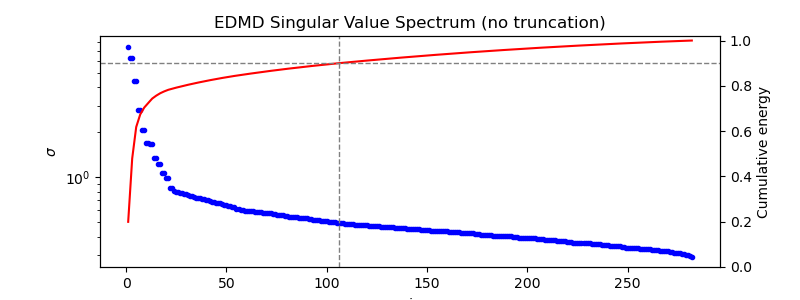

In [10]:
# ----------------------------
# Preliminary fit to set svd_rank
# ----------------------------

from pydmd import EDMD

# Delay embedding 
X2d = hankelize(X2d, d)

edmd = EDMD(svd_rank=-1,
           kernel_metric=nlsa_kernel,
           kernel_params={"epsilon": 2.0}
           ).fit(X2d)

#fig, svd_rank = plot_svd_spectrum(edmd, 2/3)
fig, svd_rank = plot_svd_spectrum(edmd, 0.9)

print(f"{svd_rank} ranks required to achieve energy threshold.")

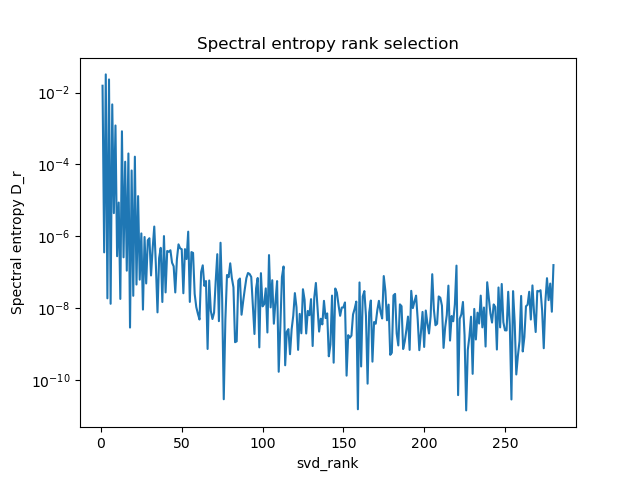

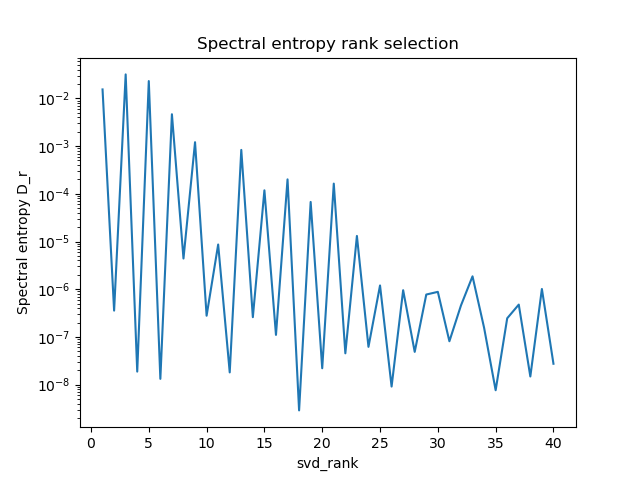

In [22]:
svalues = edmd.operator.svd_vals
spectral_entropy = []

for r in range(1,len(svalues) - 1):
    true_svalues = svalues[:r+1]
    extended_svalues = np.append(true_svalues[:r], true_svalues[r-1])
    
    p = true_svalues**2 / np.sum(true_svalues**2)
    pi = extended_svalues**2 / np.sum(extended_svalues**2)

    D_r = np.sum(p * np.log(p / pi))
    spectral_entropy.append(D_r)

print(min(spectral_entropy))

    
plt.figure()
plt.plot(range(1, len(spectral_entropy)+1), spectral_entropy)
plt.xlabel("svd_rank")
plt.ylabel("Spectral entropy D_r")
plt.yscale('log')
plt.title("Spectral entropy rank selection")
plt.show()

spectral_entropy_cropped = spectral_entropy[:40] 
plt.figure()
plt.plot(range(1, len(spectral_entropy_cropped)+1), spectral_entropy_cropped)
plt.xlabel("svd_rank")
plt.ylabel("Spectral entropy D_r")
plt.yscale('log')
plt.title("Spectral entropy rank selection")
plt.show()

In [25]:
# ----------------------------
# Fit DMD
# ----------------------------

# dmd = EDMD(svd_rank=svd_rank,
#            kernel_metric=nlsa_kernel,
#            kernel_params={"epsilon": 2.0}
#           )

dmd = EDMD(svd_rank=50,
           kernel_metric=nlsa_kernel,
           kernel_params={"epsilon": 2.0}
          )

dmd.fit(X2d)

dmd.original_time['dt'] = 1.0

/home/users/mm2947/jupyter/DMD/dmd_qbo/dmd_functions_adapted.py:415: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10, 6), constrained_layout=True)


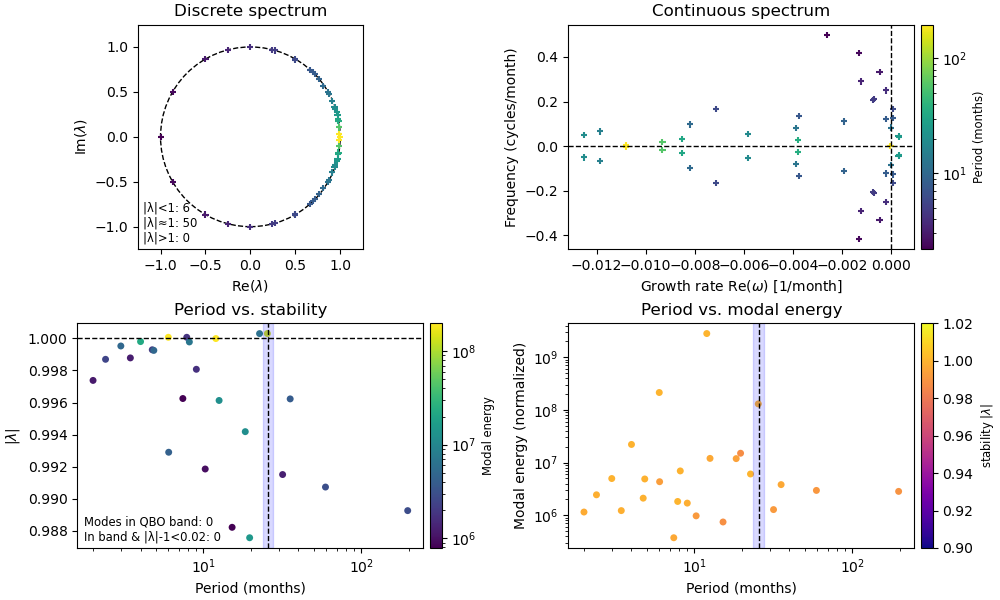

In [26]:
fig = plot_dmd_summary(dmd, dshape, d, qbo_band, qbo_period)

In [27]:
lam = np.asarray(dmd.eigs)
b = dmd.amplitudes
modes = dmd.modes
dynamics = dmd.dynamics

theta = np.angle(lam)
omega = np.log(lam) / dt
freq = np.abs(theta) / (2*np.pi*dt)
period = np.where(freq > 0, 1.0/freq, np.inf)
print(np.sort(period))
amps = np.abs(b)

[  2.           2.40015036   2.40015036   3.00001531   3.00001531
   3.44694852   3.44694852   3.99984385   3.99984385   4.74576269
   4.74576269   4.85468828   4.85468828   5.99883764   5.99883764
   6.03034793   6.03034793   7.41460858   7.41460858   7.84979173
   7.84979173   8.15221533   8.15221533   9.02885017   9.02885017
  10.27566419  10.27566419  11.9994008   11.9994008   12.58276703
  12.58276703  15.21528651  15.21528651  18.43298184  18.43298184
  19.65055345  19.65055345  22.71111871  22.71111871  25.44879003
  25.44879003  31.78785212  31.78785212  35.50228889  35.50228889
  59.42702131  59.42702131 197.24240612 197.24240612          inf]


/tmp/ipykernel_3366842/2334315218.py:9: RuntimeWarning: divide by zero encountered in divide
  period = np.where(freq > 0, 1.0/freq, np.inf)


# **DMD reconstruction from all stable modes in QBO band**

Found 2 modes in the QBO band
[25.44879003]
Found 2 stable modes in the QBO band
[25.44879003]


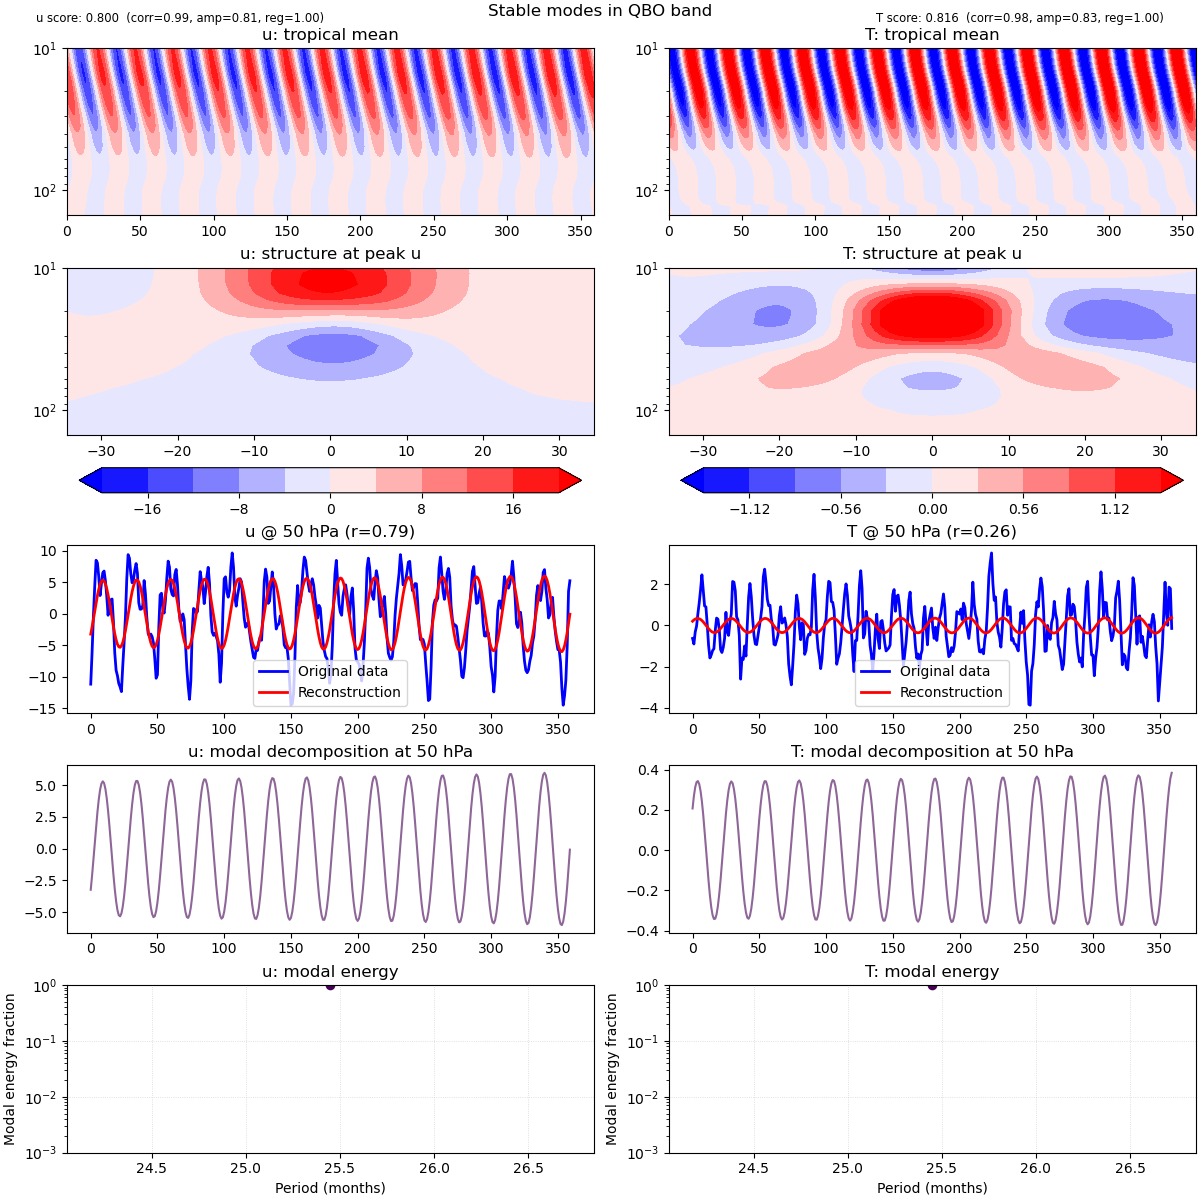

In [28]:
in_period = (period > qbo_band[0]) & (period < qbo_band[1])
print(f'Found {np.count_nonzero(in_period)} modes in the QBO band')
print(np.unique(period[in_period]))

keep_QBO = (period > qbo_band[0]) & (period < qbo_band[1]) & (np.abs(np.abs(lam) - 1.0) < stab_threshold)
dim_keep = np.count_nonzero(keep_QBO)
print(f'Found {dim_keep} stable modes in the QBO band')
print(np.unique(period[keep_QBO]))

if dim_keep == 0:
    print("No stable QBO modes found — skipping reconstruction")
    sys.exit()

else:    
    fig, out = plot_reconstruction_summary2(
        dmd, keep_QBO, d, dshape, ds, std_data, stds,
        u_levs, T_levs,
        qbo_band=qbo_band,
        lat_band=lat_band,
        pres_level=pres_plot,
        title="Stable modes in QBO band",
        return_outputs=True
    )


# **DMD reconstruction from single dominant QBO mode & its harmonics**

Identified dominant QBO mode has period 25.44879002730219
Harmonics of this dominant mode are [12.72439501 25.44879003 50.89758005]
Modes retained after filtering for stability and harmonic-like periodicity are [11.9994008  11.9994008  12.58276703 12.58276703 25.44879003 25.44879003]


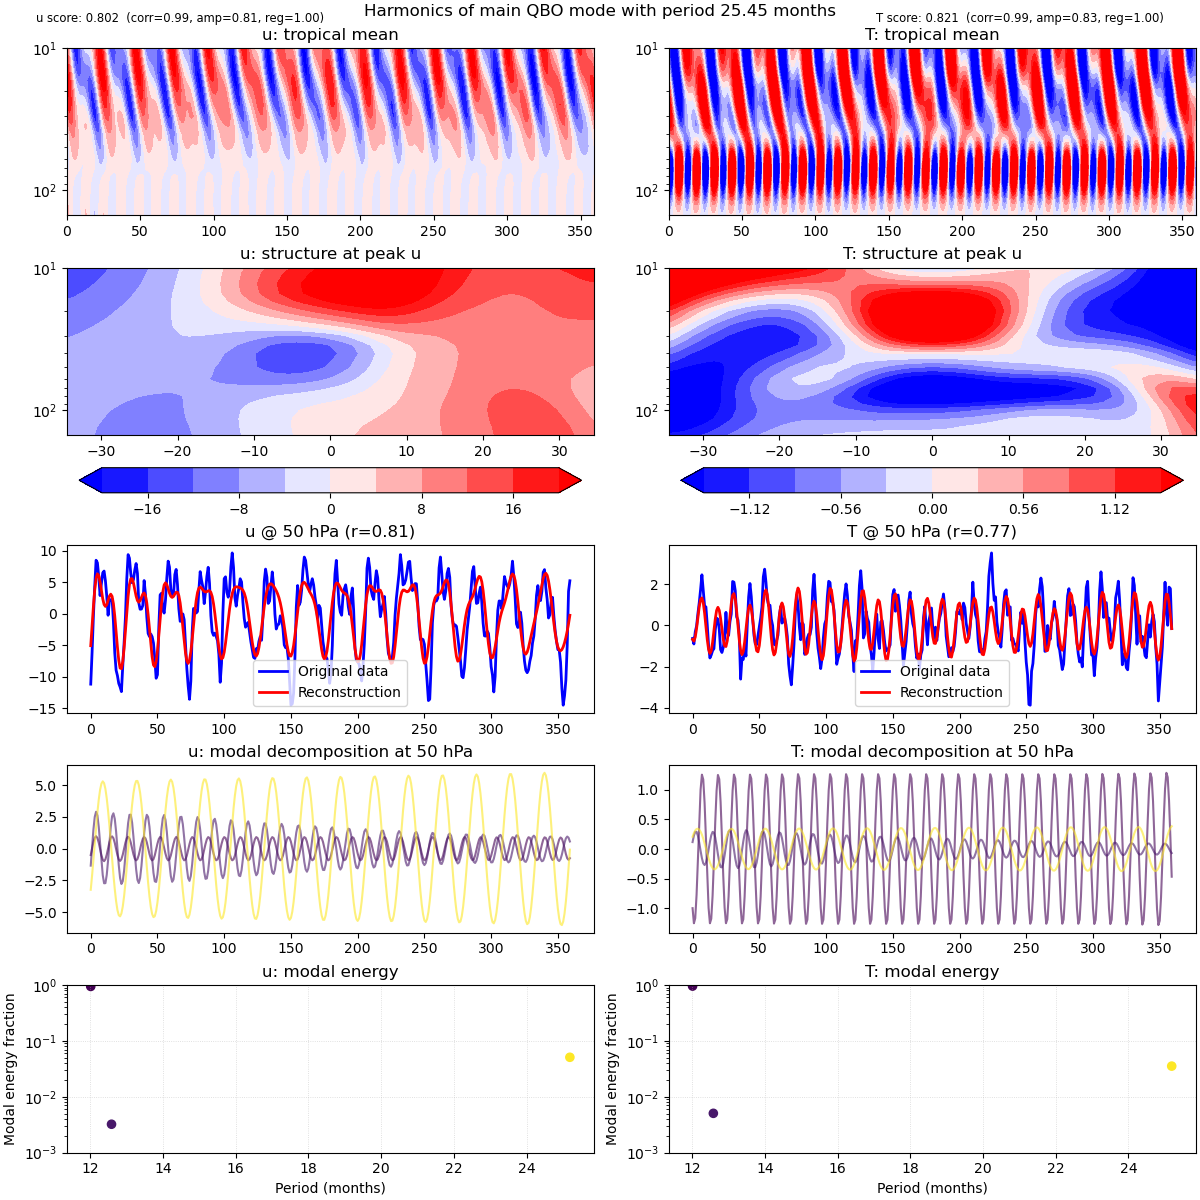

In [29]:
p0 = period[np.argmin(np.abs(period - qbo_period))]
print(f'Identified dominant QBO mode has period {p0}')

keep_harm, harm = get_harmonics(p0, period, sampfreq=1.0)
keep_stable = np.abs(np.abs(lam) - 1.0) < stab_threshold
remove_annual = (period < 12.0 - dt) | (period > 12.0 + dt) # Avoids harmonics too close to the annual cycle
keep_QBO_harm = keep_harm & keep_stable & remove_annual
    print(f'Harmonics of this dominant mode are {harm}')
print(f'Modes retained after filtering for stability and harmonic-like periodicity are {period[keep_QBO_harm]}')

fig, out_harm = plot_reconstruction_summary2(
    dmd, keep_QBO_harm, d, dshape, ds, std_data, stds,
    u_levs, T_levs,
    qbo_band = qbo_band,
    lat_band=lat_band,
    pres_level=pres_plot,
    title=f"Harmonics of main QBO mode with period {p0:.2f} months",
    return_outputs=True
)

# **DMD reconstruction from modes in QBO range & their harmonics**

[25.44879003]
[12.72439501 25.44879003 50.89758005]
[11.9994008  11.9994008  12.58276703 12.58276703 25.44879003 25.44879003]


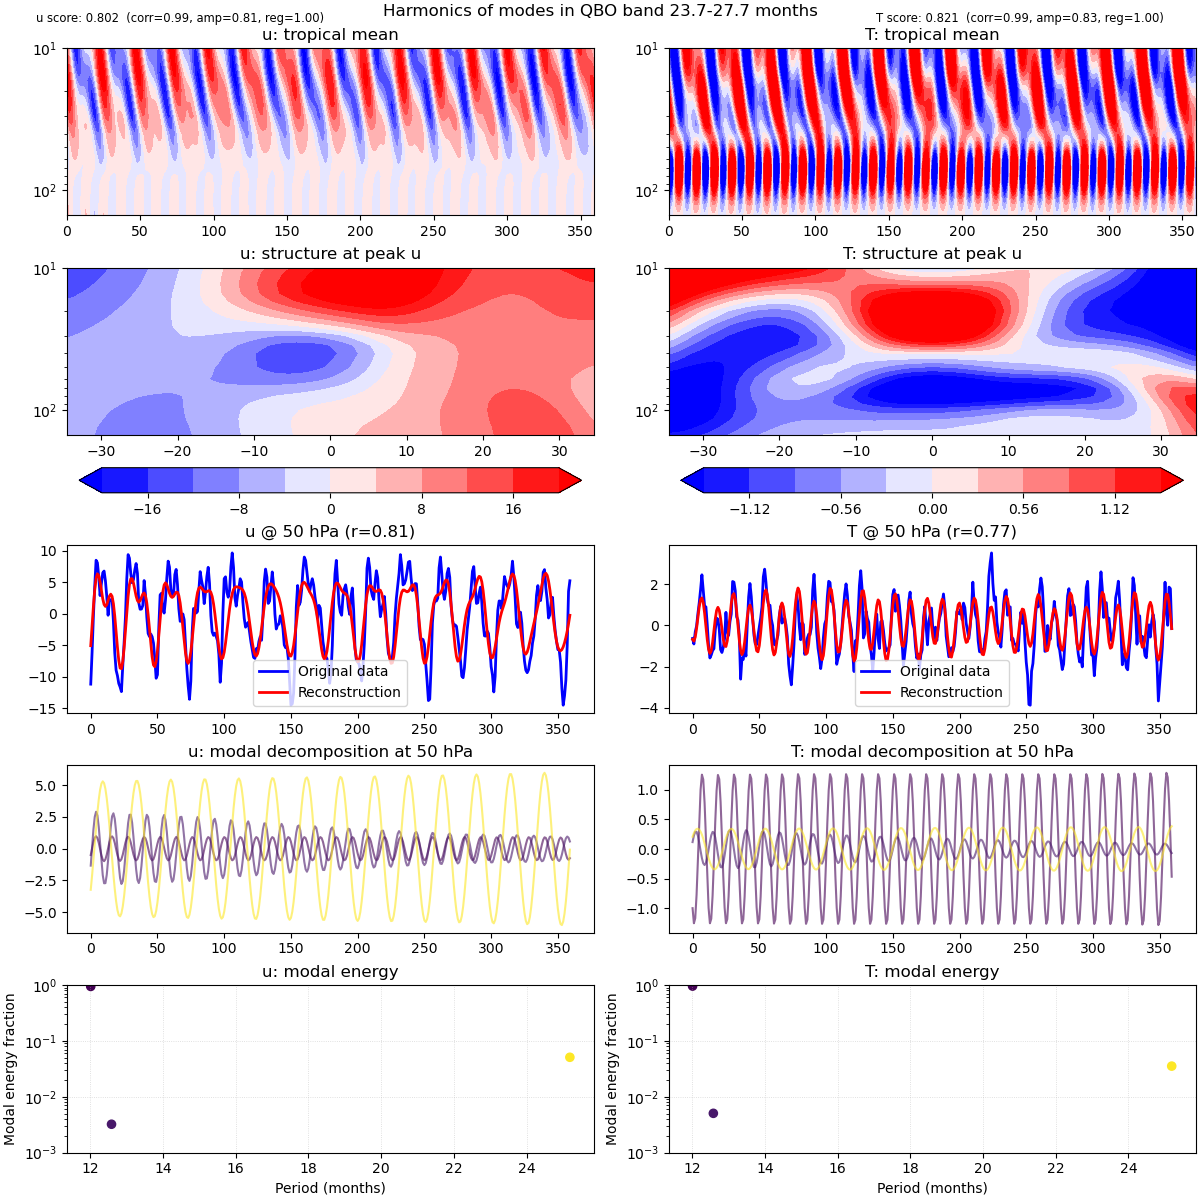

In [30]:
p0s = np.unique(period[(period > qbo_band[0]) & (period < qbo_band[1])])
print(p0s)

sf = 1.0
keep, harm = get_harmonics(p0s[0], period, sampfreq=sf)
if len(p0s) > 1:
    for p0 in p0s[1:]:
        keepnew, harmnew = get_harmonics(p0, period, sampfreq=1.0)
        keep |= keepnew
        harm = np.append(harm, harmnew)

# Stability mask
keep_stable = np.abs(np.abs(lam) - 1.0) < stab_threshold
remove_annual = (period < 12.0 - dt) | (period > 12.0 + dt) # Avoids harmonics too close to the annual cycle
keep_QBO_band_harm = keep & keep_stable & remove_annual
harm = np.unique(harm)
        
print(harm)
print(period[keep])
    
fig, out_band_harm = plot_reconstruction_summary2(
    dmd, keep_QBO_band_harm, d, dshape, ds, std_data, stds,
    u_levs, T_levs,
    qbo_band = qbo_band,
    lat_band=lat_band,
    pres_level=pres_plot,
    title=f"Harmonics of modes in QBO band {qbo_band[0]:.1f}-{qbo_band[1]:.1f} months",
    return_outputs=True
)
# if save:
#     #save_fig(fig, save_dir+"qbo_"+config_str, dpi=300)
#     fig.savefig(
#     os.path.join(save_dir, "qbo_" + file_name),
#     dpi=300,
#     bbox_inches="tight"
# )

# **Lat-Height Plots**

In [31]:
def plot_lat_height(u, T, tidx, title):

    fig, axs = plt.subplots(1,2, figsize=(12,5), constrained_layout=True)

    im0 = axs[0].contourf(lat, pres, u[:,:,tidx], levels=u_levs, cmap="bwr", extend="both")
    axs[0].set_title("u reconstruction")
    axs[0].set_xlabel("Latitude")
    axs[0].set_ylabel("Pressure (hPa)")
    axs[0].set_yscale("log")
    axs[0].invert_yaxis()
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].contourf(lat, pres, T[:,:,tidx], levels=T_levs, cmap="bwr", extend="both")
    axs[1].set_title("T reconstruction")
    axs[1].set_xlabel("Latitude")
    axs[1].set_yscale("log")
    axs[1].invert_yaxis()
    plt.colorbar(im1, ax=axs[1])

    fig.suptitle(f"{title} (t = {time[tidx]:.1f} months)")
    plt.show()


Max u time: 355.0
Min u time: 342.0


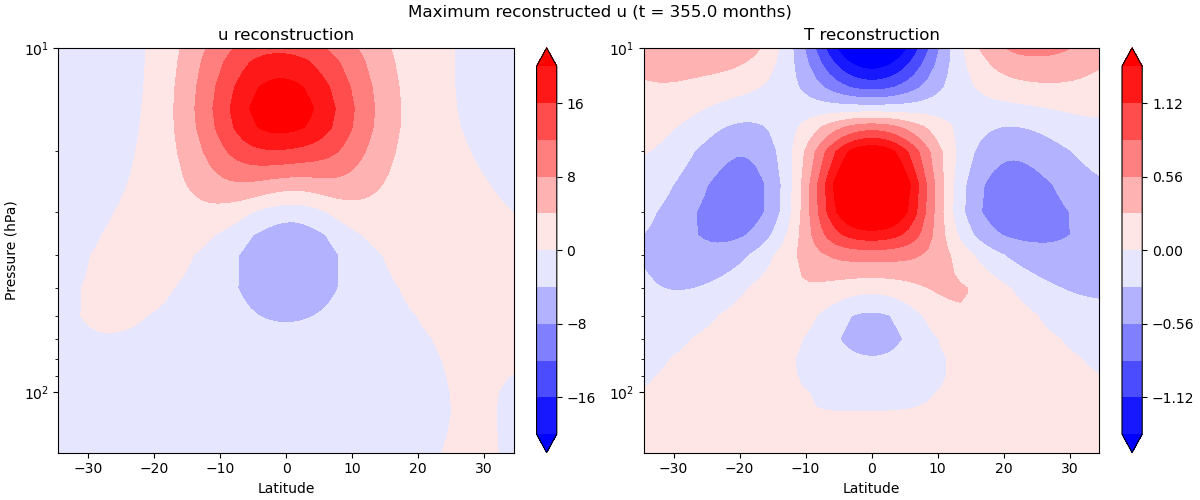

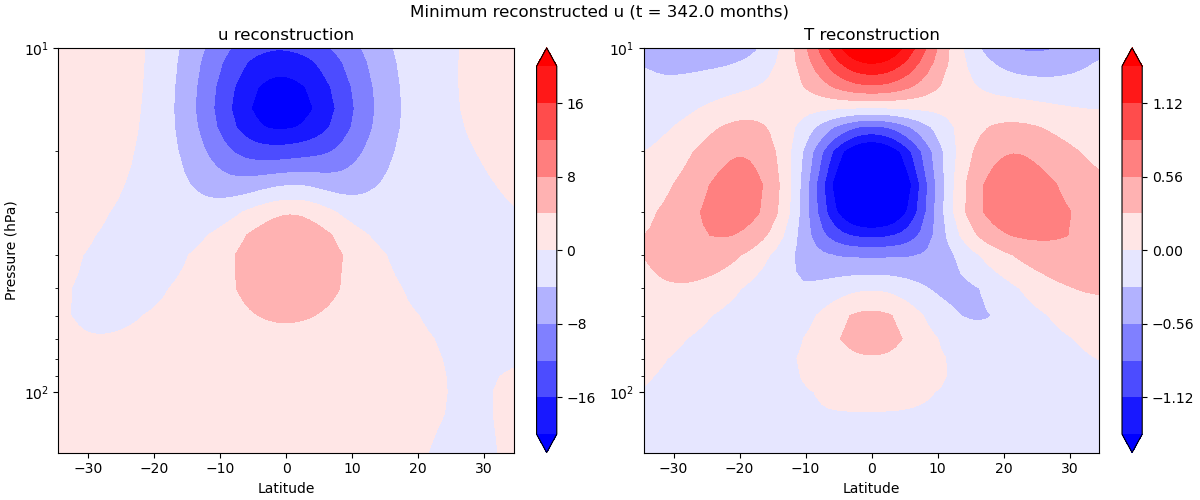

In [32]:
# Extract reconstructed fields
X_rec = out_band_harm["X_rec_phys"]
u_rec = X_rec[0]
T_rec = X_rec[1]

lat = ds.lat.values
pres = ds.pres.values
time = out_band_harm["tplot"]

# Find time indices of max and min u
tmax = np.argmax(np.max(u_rec, axis=(0,1)))
tmin = np.argmin(np.min(u_rec, axis=(0,1)))

print("Max u time:", time[tmax])
print("Min u time:", time[tmin])

plot_lat_height(u_rec, T_rec, tmax, "Maximum reconstructed u")

plot_lat_height(u_rec, T_rec, tmin, "Minimum reconstructed u")
